### obtendo os dados

In [1]:
import pandas as pd
import requests
from datetime import datetime, timedelta
from collections import Counter

In [2]:
id1 = '131'
id2 = '121'

In [3]:
url = 'https://v3.football.api-sports.io/fixtures/headtohead'

headers = {
    'x-rapidapi-host': 'v3.football.api-sports.io',
    'x-rapidapi-key': 'c71bb04ba5fcde0f4472c79fdc30a088'
}

params = {
    'h2h': f'{id1}-{id2}',
    'from': '2020-01-01',
    'to': datetime.strftime(datetime.now(),'%Y-%m-%d')
}

In [4]:
response = requests.get(url, headers=headers, params=params).json()

In [6]:
df = pd.DataFrame(response['response'])
df.head()

,fixture,league,teams,goals,score
0,"{'id': 317937, 'referee': 'Raphael Claus', 'ti...","{'id': 475, 'name': 'Paulista - A1', 'country'...","{'home': {'id': 131, 'name': 'Corinthians', 'l...","{'home': 1, 'away': 0}","{'halftime': {'home': 1, 'away': 0}, 'fulltime..."
1,"{'id': 328069, 'referee': 'Leandro Pedro Vuade...","{'id': 71, 'name': 'Serie A', 'country': 'Braz...","{'home': {'id': 131, 'name': 'Corinthians', 'l...","{'home': 0, 'away': 2}","{'halftime': {'home': 0, 'away': 1}, 'fulltime..."
2,"{'id': 579786, 'referee': 'Raphael Claus', 'ti...","{'id': 475, 'name': 'Paulista - A1', 'country'...","{'home': {'id': 131, 'name': 'Corinthians', 'l...","{'home': 0, 'away': 0}","{'halftime': {'home': 0, 'away': 0}, 'fulltime..."
3,"{'id': 654962, 'referee': 'Edina Alves Batista...","{'id': 475, 'name': 'Paulista - A1', 'country'...","{'home': {'id': 131, 'name': 'Corinthians', 'l...","{'home': 2, 'away': 2}","{'halftime': {'home': 1, 'away': 2}, 'fulltime..."
4,"{'id': 689120, 'referee': 'Raphael Claus', 'ti...","{'id': 71, 'name': 'Serie A', 'country': 'Braz...","{'home': {'id': 131, 'name': 'Corinthians', 'l...","{'home': 2, 'away': 1}","{'halftime': {'home': 1, 'away': 1}, 'fulltime..."


### criando as features e limpando o dataframe

In [7]:
def identifica_ganhador(confronto):
    if confronto['home']['winner']:
        return confronto['home']['name']
    elif confronto['away']['winner']:
        return confronto['away']['name']
    else:
        return 'Empate'

In [8]:
df['vencedor'] = df['teams'].apply(identifica_ganhador)
df.head()

,fixture,league,teams,goals,score,vencedor
0,"{'id': 317937, 'referee': 'Raphael Claus', 'ti...","{'id': 475, 'name': 'Paulista - A1', 'country'...","{'home': {'id': 131, 'name': 'Corinthians', 'l...","{'home': 1, 'away': 0}","{'halftime': {'home': 1, 'away': 0}, 'fulltime...",Corinthians
1,"{'id': 328069, 'referee': 'Leandro Pedro Vuade...","{'id': 71, 'name': 'Serie A', 'country': 'Braz...","{'home': {'id': 131, 'name': 'Corinthians', 'l...","{'home': 0, 'away': 2}","{'halftime': {'home': 0, 'away': 1}, 'fulltime...",Palmeiras
2,"{'id': 579786, 'referee': 'Raphael Claus', 'ti...","{'id': 475, 'name': 'Paulista - A1', 'country'...","{'home': {'id': 131, 'name': 'Corinthians', 'l...","{'home': 0, 'away': 0}","{'halftime': {'home': 0, 'away': 0}, 'fulltime...",Empate
3,"{'id': 654962, 'referee': 'Edina Alves Batista...","{'id': 475, 'name': 'Paulista - A1', 'country'...","{'home': {'id': 131, 'name': 'Corinthians', 'l...","{'home': 2, 'away': 2}","{'halftime': {'home': 1, 'away': 2}, 'fulltime...",Empate
4,"{'id': 689120, 'referee': 'Raphael Claus', 'ti...","{'id': 71, 'name': 'Serie A', 'country': 'Braz...","{'home': {'id': 131, 'name': 'Corinthians', 'l...","{'home': 2, 'away': 1}","{'halftime': {'home': 1, 'away': 1}, 'fulltime...",Corinthians


In [9]:
df['liga'] = df['league'].apply(lambda x: x['name'])
df.head()

,fixture,league,teams,goals,score,vencedor,liga
0,"{'id': 317937, 'referee': 'Raphael Claus', 'ti...","{'id': 475, 'name': 'Paulista - A1', 'country'...","{'home': {'id': 131, 'name': 'Corinthians', 'l...","{'home': 1, 'away': 0}","{'halftime': {'home': 1, 'away': 0}, 'fulltime...",Corinthians,Paulista - A1
1,"{'id': 328069, 'referee': 'Leandro Pedro Vuade...","{'id': 71, 'name': 'Serie A', 'country': 'Braz...","{'home': {'id': 131, 'name': 'Corinthians', 'l...","{'home': 0, 'away': 2}","{'halftime': {'home': 0, 'away': 1}, 'fulltime...",Palmeiras,Serie A
2,"{'id': 579786, 'referee': 'Raphael Claus', 'ti...","{'id': 475, 'name': 'Paulista - A1', 'country'...","{'home': {'id': 131, 'name': 'Corinthians', 'l...","{'home': 0, 'away': 0}","{'halftime': {'home': 0, 'away': 0}, 'fulltime...",Empate,Paulista - A1
3,"{'id': 654962, 'referee': 'Edina Alves Batista...","{'id': 475, 'name': 'Paulista - A1', 'country'...","{'home': {'id': 131, 'name': 'Corinthians', 'l...","{'home': 2, 'away': 2}","{'halftime': {'home': 1, 'away': 2}, 'fulltime...",Empate,Paulista - A1
4,"{'id': 689120, 'referee': 'Raphael Claus', 'ti...","{'id': 71, 'name': 'Serie A', 'country': 'Braz...","{'home': {'id': 131, 'name': 'Corinthians', 'l...","{'home': 2, 'away': 1}","{'halftime': {'home': 1, 'away': 1}, 'fulltime...",Corinthians,Serie A


In [10]:
df['rodada'] = df['league'].apply(lambda x: x['round'])
df.head()

,fixture,league,teams,goals,score,vencedor,liga,rodada
0,"{'id': 317937, 'referee': 'Raphael Claus', 'ti...","{'id': 475, 'name': 'Paulista - A1', 'country'...","{'home': {'id': 131, 'name': 'Corinthians', 'l...","{'home': 1, 'away': 0}","{'halftime': {'home': 1, 'away': 0}, 'fulltime...",Corinthians,Paulista - A1,Regular Season - 11
1,"{'id': 328069, 'referee': 'Leandro Pedro Vuade...","{'id': 71, 'name': 'Serie A', 'country': 'Braz...","{'home': {'id': 131, 'name': 'Corinthians', 'l...","{'home': 0, 'away': 2}","{'halftime': {'home': 0, 'away': 1}, 'fulltime...",Palmeiras,Serie A,Regular Season - 9
2,"{'id': 579786, 'referee': 'Raphael Claus', 'ti...","{'id': 475, 'name': 'Paulista - A1', 'country'...","{'home': {'id': 131, 'name': 'Corinthians', 'l...","{'home': 0, 'away': 0}","{'halftime': {'home': 0, 'away': 0}, 'fulltime...",Empate,Paulista - A1,Finals
3,"{'id': 654962, 'referee': 'Edina Alves Batista...","{'id': 475, 'name': 'Paulista - A1', 'country'...","{'home': {'id': 131, 'name': 'Corinthians', 'l...","{'home': 2, 'away': 2}","{'halftime': {'home': 1, 'away': 2}, 'fulltime...",Empate,Paulista - A1,Regular Season - 2
4,"{'id': 689120, 'referee': 'Raphael Claus', 'ti...","{'id': 71, 'name': 'Serie A', 'country': 'Braz...","{'home': {'id': 131, 'name': 'Corinthians', 'l...","{'home': 2, 'away': 1}","{'halftime': {'home': 1, 'away': 1}, 'fulltime...",Corinthians,Serie A,Regular Season - 22


In [11]:
df['data'] = df['fixture'].apply(lambda x: (datetime.fromisoformat(x['date']) - timedelta(hours=3)).strftime("%d/%m/%Y %H:%M"))
df.head()

,fixture,league,teams,goals,score,vencedor,liga,rodada,data
0,"{'id': 317937, 'referee': 'Raphael Claus', 'ti...","{'id': 475, 'name': 'Paulista - A1', 'country'...","{'home': {'id': 131, 'name': 'Corinthians', 'l...","{'home': 1, 'away': 0}","{'halftime': {'home': 1, 'away': 0}, 'fulltime...",Corinthians,Paulista - A1,Regular Season - 11,22/07/2020 21:30
1,"{'id': 328069, 'referee': 'Leandro Pedro Vuade...","{'id': 71, 'name': 'Serie A', 'country': 'Braz...","{'home': {'id': 131, 'name': 'Corinthians', 'l...","{'home': 0, 'away': 2}","{'halftime': {'home': 0, 'away': 1}, 'fulltime...",Palmeiras,Serie A,Regular Season - 9,10/09/2020 19:15
2,"{'id': 579786, 'referee': 'Raphael Claus', 'ti...","{'id': 475, 'name': 'Paulista - A1', 'country'...","{'home': {'id': 131, 'name': 'Corinthians', 'l...","{'home': 0, 'away': 0}","{'halftime': {'home': 0, 'away': 0}, 'fulltime...",Empate,Paulista - A1,Finals,05/08/2020 21:30
3,"{'id': 654962, 'referee': 'Edina Alves Batista...","{'id': 475, 'name': 'Paulista - A1', 'country'...","{'home': {'id': 131, 'name': 'Corinthians', 'l...","{'home': 2, 'away': 2}","{'halftime': {'home': 1, 'away': 2}, 'fulltime...",Empate,Paulista - A1,Regular Season - 2,03/03/2021 19:00
4,"{'id': 689120, 'referee': 'Raphael Claus', 'ti...","{'id': 71, 'name': 'Serie A', 'country': 'Braz...","{'home': {'id': 131, 'name': 'Corinthians', 'l...","{'home': 2, 'away': 1}","{'halftime': {'home': 1, 'away': 1}, 'fulltime...",Corinthians,Serie A,Regular Season - 22,25/09/2021 19:00


In [12]:
df['arbitro'] = df['fixture'].apply(lambda x: x['referee'])
df.head()

,fixture,league,teams,goals,score,vencedor,liga,rodada,data,arbitro
0,"{'id': 317937, 'referee': 'Raphael Claus', 'ti...","{'id': 475, 'name': 'Paulista - A1', 'country'...","{'home': {'id': 131, 'name': 'Corinthians', 'l...","{'home': 1, 'away': 0}","{'halftime': {'home': 1, 'away': 0}, 'fulltime...",Corinthians,Paulista - A1,Regular Season - 11,22/07/2020 21:30,Raphael Claus
1,"{'id': 328069, 'referee': 'Leandro Pedro Vuade...","{'id': 71, 'name': 'Serie A', 'country': 'Braz...","{'home': {'id': 131, 'name': 'Corinthians', 'l...","{'home': 0, 'away': 2}","{'halftime': {'home': 0, 'away': 1}, 'fulltime...",Palmeiras,Serie A,Regular Season - 9,10/09/2020 19:15,"Leandro Pedro Vuaden, Brazil"
2,"{'id': 579786, 'referee': 'Raphael Claus', 'ti...","{'id': 475, 'name': 'Paulista - A1', 'country'...","{'home': {'id': 131, 'name': 'Corinthians', 'l...","{'home': 0, 'away': 0}","{'halftime': {'home': 0, 'away': 0}, 'fulltime...",Empate,Paulista - A1,Finals,05/08/2020 21:30,Raphael Claus
3,"{'id': 654962, 'referee': 'Edina Alves Batista...","{'id': 475, 'name': 'Paulista - A1', 'country'...","{'home': {'id': 131, 'name': 'Corinthians', 'l...","{'home': 2, 'away': 2}","{'halftime': {'home': 1, 'away': 2}, 'fulltime...",Empate,Paulista - A1,Regular Season - 2,03/03/2021 19:00,Edina Alves Batista
4,"{'id': 689120, 'referee': 'Raphael Claus', 'ti...","{'id': 71, 'name': 'Serie A', 'country': 'Braz...","{'home': {'id': 131, 'name': 'Corinthians', 'l...","{'home': 2, 'away': 1}","{'halftime': {'home': 1, 'away': 1}, 'fulltime...",Corinthians,Serie A,Regular Season - 22,25/09/2021 19:00,Raphael Claus


In [13]:
df['mando_de_campo'] = df['teams'].apply(lambda x: x['home']['name'])
df.head()

,fixture,league,teams,goals,score,vencedor,liga,rodada,data,arbitro,mando_de_campo
0,"{'id': 317937, 'referee': 'Raphael Claus', 'ti...","{'id': 475, 'name': 'Paulista - A1', 'country'...","{'home': {'id': 131, 'name': 'Corinthians', 'l...","{'home': 1, 'away': 0}","{'halftime': {'home': 1, 'away': 0}, 'fulltime...",Corinthians,Paulista - A1,Regular Season - 11,22/07/2020 21:30,Raphael Claus,Corinthians
1,"{'id': 328069, 'referee': 'Leandro Pedro Vuade...","{'id': 71, 'name': 'Serie A', 'country': 'Braz...","{'home': {'id': 131, 'name': 'Corinthians', 'l...","{'home': 0, 'away': 2}","{'halftime': {'home': 0, 'away': 1}, 'fulltime...",Palmeiras,Serie A,Regular Season - 9,10/09/2020 19:15,"Leandro Pedro Vuaden, Brazil",Corinthians
2,"{'id': 579786, 'referee': 'Raphael Claus', 'ti...","{'id': 475, 'name': 'Paulista - A1', 'country'...","{'home': {'id': 131, 'name': 'Corinthians', 'l...","{'home': 0, 'away': 0}","{'halftime': {'home': 0, 'away': 0}, 'fulltime...",Empate,Paulista - A1,Finals,05/08/2020 21:30,Raphael Claus,Corinthians
3,"{'id': 654962, 'referee': 'Edina Alves Batista...","{'id': 475, 'name': 'Paulista - A1', 'country'...","{'home': {'id': 131, 'name': 'Corinthians', 'l...","{'home': 2, 'away': 2}","{'halftime': {'home': 1, 'away': 2}, 'fulltime...",Empate,Paulista - A1,Regular Season - 2,03/03/2021 19:00,Edina Alves Batista,Corinthians
4,"{'id': 689120, 'referee': 'Raphael Claus', 'ti...","{'id': 71, 'name': 'Serie A', 'country': 'Braz...","{'home': {'id': 131, 'name': 'Corinthians', 'l...","{'home': 2, 'away': 1}","{'halftime': {'home': 1, 'away': 1}, 'fulltime...",Corinthians,Serie A,Regular Season - 22,25/09/2021 19:00,Raphael Claus,Corinthians


In [14]:
df['placar'] = df['goals'].apply(lambda x: f"{x['home']}x{x['away']}")
df.head()

,fixture,league,teams,goals,score,vencedor,liga,rodada,data,arbitro,mando_de_campo,placar
0,"{'id': 317937, 'referee': 'Raphael Claus', 'ti...","{'id': 475, 'name': 'Paulista - A1', 'country'...","{'home': {'id': 131, 'name': 'Corinthians', 'l...","{'home': 1, 'away': 0}","{'halftime': {'home': 1, 'away': 0}, 'fulltime...",Corinthians,Paulista - A1,Regular Season - 11,22/07/2020 21:30,Raphael Claus,Corinthians,1x0
1,"{'id': 328069, 'referee': 'Leandro Pedro Vuade...","{'id': 71, 'name': 'Serie A', 'country': 'Braz...","{'home': {'id': 131, 'name': 'Corinthians', 'l...","{'home': 0, 'away': 2}","{'halftime': {'home': 0, 'away': 1}, 'fulltime...",Palmeiras,Serie A,Regular Season - 9,10/09/2020 19:15,"Leandro Pedro Vuaden, Brazil",Corinthians,0x2
2,"{'id': 579786, 'referee': 'Raphael Claus', 'ti...","{'id': 475, 'name': 'Paulista - A1', 'country'...","{'home': {'id': 131, 'name': 'Corinthians', 'l...","{'home': 0, 'away': 0}","{'halftime': {'home': 0, 'away': 0}, 'fulltime...",Empate,Paulista - A1,Finals,05/08/2020 21:30,Raphael Claus,Corinthians,0x0
3,"{'id': 654962, 'referee': 'Edina Alves Batista...","{'id': 475, 'name': 'Paulista - A1', 'country'...","{'home': {'id': 131, 'name': 'Corinthians', 'l...","{'home': 2, 'away': 2}","{'halftime': {'home': 1, 'away': 2}, 'fulltime...",Empate,Paulista - A1,Regular Season - 2,03/03/2021 19:00,Edina Alves Batista,Corinthians,2x2
4,"{'id': 689120, 'referee': 'Raphael Claus', 'ti...","{'id': 71, 'name': 'Serie A', 'country': 'Braz...","{'home': {'id': 131, 'name': 'Corinthians', 'l...","{'home': 2, 'away': 1}","{'halftime': {'home': 1, 'away': 1}, 'fulltime...",Corinthians,Serie A,Regular Season - 22,25/09/2021 19:00,Raphael Claus,Corinthians,2x1


In [17]:
df = df[['data','liga','rodada','arbitro','mando_de_campo','vencedor','placar']]
df.head()

,data,liga,rodada,arbitro,mando_de_campo,vencedor,placar
0,22/07/2020 21:30,Paulista - A1,Regular Season - 11,Raphael Claus,Corinthians,Corinthians,1x0
1,10/09/2020 19:15,Serie A,Regular Season - 9,"Leandro Pedro Vuaden, Brazil",Corinthians,Palmeiras,0x2
2,05/08/2020 21:30,Paulista - A1,Finals,Raphael Claus,Corinthians,Empate,0x0
3,03/03/2021 19:00,Paulista - A1,Regular Season - 2,Edina Alves Batista,Corinthians,Empate,2x2
4,25/09/2021 19:00,Serie A,Regular Season - 22,Raphael Claus,Corinthians,Corinthians,2x1


### quantidade de vitórias de cada time

In [36]:
df['vencedor'].value_counts()

vencedor
Palmeiras      9
Empate         7
Corinthians    3
Name: count, dtype: int64

<Axes: >

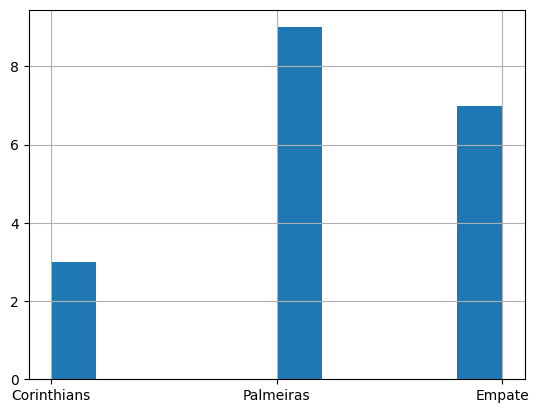

In [39]:
df['vencedor'].hist()

### quantidade de vitórias em casa

In [45]:
vitorias = []
for idx, val in df.iterrows():
    if val['vencedor'] == val['mando_de_campo']:
        vitorias.append(val['vencedor'])

In [55]:
dict(Counter(vitorias))

{'Corinthians': 3, 'Palmeiras': 6}

### quantidade de vitórias fora de casa ou empates

In [56]:
vitorias_fora = []
for idx, val in df.iterrows():
    if val['vencedor'] != val['mando_de_campo']:
        vitorias_fora.append(val['vencedor'])

In [57]:
dict(Counter(vitorias_fora))

{'Palmeiras': 3, 'Empate': 7}

### listagem completa do dataframe (caso queira exportar para excel)

In [58]:
df

,data,liga,rodada,arbitro,mando_de_campo,vencedor,placar
0,22/07/2020 21:30,Paulista - A1,Regular Season - 11,Raphael Claus,Corinthians,Corinthians,1x0
1,10/09/2020 19:15,Serie A,Regular Season - 9,"Leandro Pedro Vuaden, Brazil",Corinthians,Palmeiras,0x2
2,05/08/2020 21:30,Paulista - A1,Finals,Raphael Claus,Corinthians,Empate,0x0
3,03/03/2021 19:00,Paulista - A1,Regular Season - 2,Edina Alves Batista,Corinthians,Empate,2x2
4,25/09/2021 19:00,Serie A,Regular Season - 22,Raphael Claus,Corinthians,Corinthians,2x1
5,16/05/2021 16:00,Paulista - A1,Semi-finals,Flavio Rodrigues De Souza,Corinthians,Palmeiras,0x2
6,13/08/2022 19:00,Serie A,Regular Season - 22,Raphael Claus,Corinthians,Palmeiras,0x1
7,16/02/2023 21:30,Paulista - A1,Regular Season - 9,Raphael Claus,Corinthians,Empate,2x2
8,03/09/2023 16:00,Serie A,Regular Season - 22,Anderson Daronco,Corinthians,Empate,0x0
9,04/11/2024 20:00,Serie A,Regular Season - 32,Wilton Pereira Sampaio,Corinthians,Corinthians,2x0
